In [ ]:
#XLMRoBERTa model training
import pandas as pd
import re
import os
import numpy as np
from random import random
os.environ["WANDB_DISABLED"] = "true"
from google.colab import drive
from sklearn.model_selection import KFold, train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sentence_transformers import SentenceTransformer, util

# Mount Google Drive
drive.mount('/content/drive')

# Load and clean dataset
file_path = '/content/drive/MyDrive/data2/mixeddataset.xlsx'
df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.astype(str).str.strip().str.lower().str.replace(r'\ufeff', '', regex=True)
print("Columns after cleaning:", df.columns.tolist())

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[^ -~]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join(text.split()[:500])

df = df.rename(columns={
    'subject': 'subject', 'Subject': 'subject',
    'body': 'body', 'Body': 'body',
    'label': 'label', 'Label': 'label'
})

df['subject'] = df['subject'].apply(preprocess_text)
df['body'] = df['body'].apply(preprocess_text)
df['text'] = (df['subject'] + ' ' + df['body']).str.strip()
df['label'] = pd.to_numeric(df['label'], errors='coerce').astype('Int64')

df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.len() > 5]
df = df[~df['text'].str.contains('#ERROR!', na=False)]
print(f"Rows after basic cleaning: {len(df)}")

# Remove exact duplicates
df = df.drop_duplicates(subset=['text'], keep='first')
print(f"Rows after removing exact duplicates: {len(df)}")

# Near-duplicate removal
if len(df) >= 10:
    print("Checking near-duplicates (cosine similarity > 0.70)...")  # ← changed
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = embedder.encode(df['text'].tolist(), batch_size=32, show_progress_bar=True)
    cos_sim = util.cos_sim(embeddings, embeddings)
    threshold = 0.70          # ← CHANGED from 0.88 to 0.70
    to_remove = set()
    for i in range(len(cos_sim)):
        for j in range(i + 1, len(cos_sim)):
            if cos_sim[i, j] > threshold:
                to_remove.add(j)
    df = df.drop(index=df.index[list(to_remove)])
    print(f"Near-duplicates removed: {len(to_remove)}")
else:
    print("Dataset too small → skipping near-duplicate removal")

print(f"Rows after near-dedup: {len(df)}")

df, _ = train_test_split(
    df,
    test_size=0.30,                  
    random_state=42,
    stratify=df['label'] if len(df['label'].unique()) > 1 else None
)
print(f"Final number of rows after 70% subsample: {len(df)}")

# XLM-RoBERTa setup
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128        # ← CHANGED from 512 to 128
    )

# Metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Training function
def train_model(train_ds, eval_ds, output_dir, epochs=2):   # ← epochs default 3→2
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    
    model.config.hidden_dropout_prob = 0.30         # ← was 0.50
    model.config.attention_probs_dropout_prob = 0.30  # ← was 0.50
    model.classifier.dropout.p = 0.30               # ← was 0.60

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,                    # ← 2 epochs (was 3/4)
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=1,
        warmup_ratio=0.10,                          # ← was 0.30 (abrupt LR ramp-up)
        weight_decay=0.10,                          # ← was 0.35 (less L2 penalty)
        learning_rate=3e-5,                         # ← was 4e-6 (larger, noisier updates)
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=30,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        label_smoothing_factor=0.05,                # ← was 0.18 (harder targets)
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # ← was 1
    )

    trainer.train()
    return trainer

# 5-FOLD CROSS VALIDATION
print("\n===== Starting 5-Fold Cross-Validation =====")
fold_metrics = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
    print(f"\n===== Fold {fold + 1}/5 =====")
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_dataset = Dataset.from_pandas(train_df[['text', 'label']]).map(tokenize_function, batched=True)
    val_dataset = Dataset.from_pandas(val_df[['text', 'label']]).map(tokenize_function, batched=True)

    train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

    output_dir = f'/content/drive/MyDrive/bertmixeddataset/xlmr_fold_{fold + 1}'
    trainer = train_model(train_dataset, val_dataset, output_dir, epochs=2)  # ← 2 epochs

    metrics = trainer.evaluate()
    fold_metrics.append(metrics)
    print(f"Fold {fold+1} metrics → {metrics}")

if fold_metrics:
    avg_f1  = np.mean([m['eval_f1']       for m in fold_metrics])
    avg_acc = np.mean([m['eval_accuracy']  for m in fold_metrics])
    print("\n" + "="*50)
    print(f"5-Fold CV Average → Accuracy: {avg_acc:.4f} | F1: {avg_f1:.4f}")
    print("="*50)

# FINAL TRAINING (80/20 split)
print("\n===== Final Model Training (80/20 split) =====")
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label'] if len(df['label'].unique()) > 1 else None
)

train_dataset = Dataset.from_pandas(train_df[['text', 'label']]).map(tokenize_function, batched=True)
val_dataset   = Dataset.from_pandas(val_df[['text', 'label']]).map(tokenize_function, batched=True)

train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

final_output_dir = '/content/drive/MyDrive/bertmixeddataset/xlmr_final'
trainer = train_model(train_dataset, val_dataset, final_output_dir, epochs=2)

# Final evaluation
final_metrics = trainer.evaluate()
final_acc = final_metrics['eval_accuracy']
final_f1  = final_metrics['eval_f1']
final_precision = final_metrics['eval_precision']
final_recall    = final_metrics['eval_recall']

print("\n" + "═"*60)
print("FINAL MODEL PERFORMANCE (validation set):")
print(f"Accuracy  : {final_acc:.4f}  ({final_acc*100:.2f}%)")
print(f"F1-Score  : {final_f1:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print("═"*60)

# Save best model
final_save_path = '/content/drive/MyDrive/bertmixeddataset/xlmr_final_model'
trainer.model.save_pretrained(final_save_path)
tokenizer.save_pretrained(final_save_path)

print(f"\nModel saved successfully → {final_save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columns after cleaning: ['subject', 'body', 'label']
Rows after basic cleaning: 3993
Rows after removing exact duplicates: 3992
Checking near-duplicates (cosine similarity > 0.70)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Near-duplicates removed: 2295
Rows after near-dedup: 1697
Final number of rows after 70% subsample: 1187


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


════════════════════════════════════════════════════════════
FINAL MODEL PERFORMANCE (validation set):
Accuracy  : 0.9244  (92.44%)
F1-Score  : 0.8571
Precision : 0.8060
Recall    : 0.9153
════════════════════════════════════════════════════════════


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved successfully → /content/drive/MyDrive/bertmixeddataset/xlmr_final_model


In [2]:
# Install required libraries (matching your versions)
!pip install --no-cache-dir -q transformers==4.37.2 torch==2.1.0

# ────────────────────────────────────────────────
# IMPORTS
# ────────────────────────────────────────────────
import re
import os
import torch
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Mount Google Drive
drive.mount('/content/drive', force_remount=False)

# ────────────────────────────────────────────────
# MODEL PATH  ← updated to match training output
# ────────────────────────────────────────────────
model_path = '/content/drive/MyDrive/bertmixeddataset/xlmr_final_model'

if os.path.exists(model_path):
    print(f"Model folder found at: {model_path}")
    !ls -lh "{model_path}" | grep -E "pytorch_model|config|tokenizer|vocab|sentencepiece|model.safetensors" || echo "(some files may still be missing)"
else:
    print(f"Error: Model folder not found at {model_path}")
    print("Searching for similar folders:")
    !find '/content/drive/MyDrive/' -maxdepth 5 -type d -name "*xlmr*" 2>/dev/null | head -n 8
    raise FileNotFoundError(f"Model not found → {model_path}")

# ────────────────────────────────────────────────
# LOAD MODEL & TOKENIZER
# ────────────────────────────────────────────────
try:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(f"\nXLM-RoBERTa loaded successfully! Running on: {device}\n")
except Exception as e:
    print("Failed to load model or tokenizer:")
    raise e

# ────────────────────────────────────────────────
# PREPROCESSING (same as training)
# ────────────────────────────────────────────────
def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[^ -~]+', ' ', text)   # matches training: strips non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join(text.split()[:500])

# ────────────────────────────────────────────────
# MULTILINE INPUT HELPER
# Paste as many lines as you want, then type END
# on its own line and press Enter to finish.
# ────────────────────────────────────────────────
def multiline_input(prompt: str) -> str:
    print(prompt)
    print("  (paste your text — when done, type  END  on a new line and press Enter)")
    lines = []
    while True:
        try:
            line = input()
        except EOFError:
            break
        if line.strip().upper() == "END":
            break
        lines.append(line)
    return "\n".join(lines).strip()

# ────────────────────────────────────────────────
# PREDICTION FUNCTION
# ────────────────────────────────────────────────
def predict_email(subject: str, body: str):
    combined = (subject + " " + body).strip()
    full_text = preprocess_text(combined)

    if len(full_text.strip()) < 5:
        return "Input too short / empty", 0.0, [0.0, 0.0]

    inputs = tokenizer(
        full_text,
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=128          # ← matches training (was 512 in old test code)
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()
    prediction = int(torch.argmax(logits, dim=1).item())

    label = "Phishing" if prediction == 1 else "Legitimate"
    confidence = float(probabilities[prediction])

    return label, confidence, [float(probabilities[0]), float(probabilities[1])]

# ────────────────────────────────────────────────
# MANUAL TESTING LOOP
# ────────────────────────────────────────────────
print("=" * 55)
print("  Email Phishing Detector — Manual Test Mode")
print("  Type  QUIT  as subject to exit at any time.")
print("=" * 55 + "\n")

while True:
    # ── Subject ──────────────────────────────────
    subject = multiline_input("EMAIL SUBJECT:")

    if subject.strip().upper() == "QUIT":
        print("Exiting. Goodbye!")
        break

    # ── Body ─────────────────────────────────────
    body = multiline_input("EMAIL BODY:")

    if not body:
        print("No body provided — skipping.\n")
        continue

    # ── Predict ──────────────────────────────────
    label, confidence, probs = predict_email(subject, body)

    print("\n" + "═" * 55)
    print(f"  Subject   : {subject[:80] if subject else '(no subject)'}")
    print(f"  Body      : {body[:80]}{'...' if len(body) > 80 else ''}")
    print(f"  Prediction: {label}")
    print(f"  Confidence: {confidence * 100:.2f}%")
    print(f"  Prob → Legitimate: {probs[0]:.4f}  |  Phishing: {probs[1]:.4f}")
    print("═" * 55 + "\n")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 25.6 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==2.1.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model folder found at: /content/drive/MyDrive/bertmixeddataset/xlmr_final_model
-rw------- 1 root root  762 Mar 13 14:08 config.json
-rw------- 1 root root 1.1G Mar 13 14:08 model.safetensors
-rw------- 1 root root 4.9M Jan 22 07:52 sentencepiece.bpe.model
-rw------- 1 root root  314 Mar 13 14:08 tokenizer_config.json
-rw------- 1 root root  17M Mar 13 14:08 tokenizer.json


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


XLM-RoBERTa loaded successfully! Running on: cuda

  Email Phishing Detector — Manual Test Mode
  Type  QUIT  as subject to exit at any time.

EMAIL SUBJECT:
  (paste your text — when done, type  END  on a new line and press Enter)
Fwd: Dear, nandanaanandp@gmail.com!
END
EMAIL BODY:
  (paste your text — when done, type  END  on a new line and press Enter)
We are pleased to inform you that your previously lost funds from internet fraud have been reclaimed by the American government.  Your funds and ROI have been deposited with a Credit Union. Please reply to this message and provide your full name and INC ID for assistance with your deposit.  Your deposit request ID: INC  Best regards, Stephen Laurance American Federal Trade Commission
END

═══════════════════════════════════════════════════════
  Subject   : Fwd: Dear, nandanaanandp@gmail.com!
  Body      : We are pleased to inform you that your previously lost funds from internet fraud...
  Prediction: Phishing
  Confidence: 96.93%
 

KeyboardInterrupt: Interrupted by user

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLM-RoBERTa model loaded successfully
Original dataset: 4001
After exact dedup: 3992
Train samples : 3018
Test  samples : 755

Training Distribution
  Legitimate: 1512
  Phishing  : 1506

Testing Distribution
  Legitimate: 378
  Phishing  : 377


Predicting: 100%|██████████| 48/48 [00:06<00:00,  7.27it/s]


<Figure size 600x500 with 0 Axes>

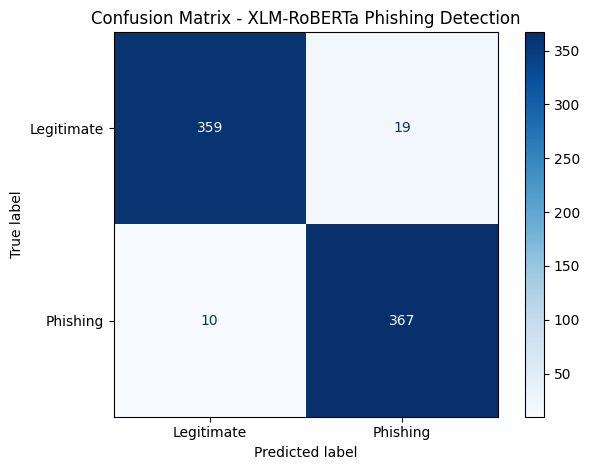

Confusion matrix saved.


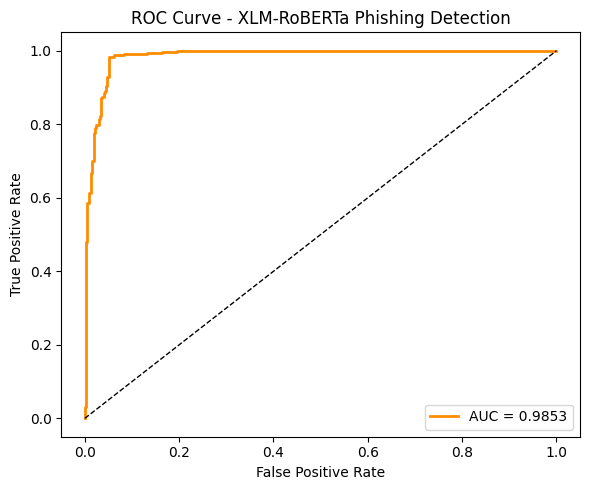

ROC curve saved. AUC = 0.9853

Classification Report

              precision    recall  f1-score   support

  Legitimate       0.97      0.95      0.96       378
    Phishing       0.95      0.97      0.96       377

    accuracy                           0.96       755
   macro avg       0.96      0.96      0.96       755
weighted avg       0.96      0.96      0.96       755



In [5]:
# ==========================================
# XLM-RoBERTa CONFUSION MATRIX + ROC CURVE
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import torch
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# LOAD TRAINED XLM-RoBERTa MODEL
# ==========================================

model_path = "/content/drive/MyDrive/bertmixeddataset/xlmr_final_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model     = AutoModelForSequenceClassification.from_pretrained(model_path)

model.to(device)
model.eval()
print("XLM-RoBERTa model loaded successfully")

# ==========================================
# LOAD DATASET
# ==========================================

file_path = "/content/drive/MyDrive/data2/mixeddataset.xlsx"
df = pd.read_excel(file_path)

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace('\ufeff', '', regex=False)
)
print("Original dataset:", len(df))

# ==========================================
# PREPROCESSING
# ==========================================

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[^ -~]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join(text.split()[:500])

df['subject'] = df['subject'].apply(preprocess_text)
df['body']    = df['body'].apply(preprocess_text)
df['text']    = (df['subject'] + ' ' + df['body']).str.strip()
df['label']   = pd.to_numeric(df['label'], errors='coerce').astype('Int64')

df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.len() > 5]
df = df[~df['text'].str.contains('#ERROR!', na=False)]

# ==========================================
# REMOVE EXACT DUPLICATES
# ==========================================

df = df.drop_duplicates(subset=['text'])
print("After exact dedup:", len(df))

TRAIN_SIZE = 3018
TEST_SIZE  = 755
TOTAL      = TRAIN_SIZE + TEST_SIZE

if len(df) < TOTAL:
    raise ValueError(
        f"Not enough rows: have {len(df)}, need {TOTAL}. "
        "Check your dataset for missing/corrupt rows."
    )

# ==========================================
# STRATIFIED SPLIT
# ==========================================

df_sampled, _ = train_test_split(
    df,
    train_size=TOTAL,
    random_state=42,
    stratify=df['label'] if df['label'].nunique() > 1 else None
)

train_df, val_df = train_test_split(
    df_sampled,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=df_sampled['label'] if df_sampled['label'].nunique() > 1 else None
)

assert len(train_df) == TRAIN_SIZE
assert len(val_df)   == TEST_SIZE

print(f"Train samples : {len(train_df)}")
print(f"Test  samples : {len(val_df)}")

# ==========================================
# DATA DISTRIBUTION
# ==========================================

train_counts = train_df['label'].value_counts()
test_counts  = val_df['label'].value_counts()

print("\nTraining Distribution")
print("  Legitimate:", train_counts.get(0, 0))
print("  Phishing  :", train_counts.get(1, 0))

print("\nTesting Distribution")
print("  Legitimate:", test_counts.get(0, 0))
print("  Phishing  :", test_counts.get(1, 0))

texts  = val_df['text'].tolist()
labels = val_df['label'].tolist()

# ==========================================
# RUN PREDICTIONS
# ==========================================

batch_size = 16
all_preds  = []
all_probs  = []

for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
    batch = texts[i:i + batch_size]

    encodings = tokenizer(
        batch,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings)

    logits = outputs.logits
    probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds  = torch.argmax(logits, dim=1).cpu().numpy()

    all_probs.extend(probs)
    all_preds.extend(preds)

preds = np.array(all_preds)
probs = np.array(all_probs)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm   = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - XLM-RoBERTa Phishing Detection")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/bertmixeddataset/xlmr_confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved.")

# ==========================================
# ROC CURVE
# ==========================================

fpr, tpr, _ = roc_curve(labels, probs)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XLM-RoBERTa Phishing Detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/bertmixeddataset/xlmr_roc_curve.png", dpi=150)
plt.show()
print(f"ROC curve saved. AUC = {roc_auc:.4f}")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report\n")
print(classification_report(labels, preds, target_names=["Legitimate", "Phishing"]))